In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ml_users = pd.read_csv("C:\\Users\\admin\\ML_RESUME_PROJECT\\user_features.csv")

print("Dataset shape:", ml_users.shape)
ml_users.head()

Dataset shape: (32820, 28)


,user_id,session_count,total_impressions,total_clicks,history_length,overall_ctr,total_articles_consumed,autos_share,entertainment_share,finance_share,...,northamerica_share,sports_share,travel_share,tv_share,video_share,weather_share,content_entropy,dominant_category_share,dominant_category,categories_engaged
0,U100,1,105,1,10,0.009524,11,0.000000,0.000000,0.000000,...,0.0,0.181818,0.000000,0.363636,0.0,0.000000,1.515708,0.363636,tv,5
1,U10001,2,84,3,15,0.035714,18,0.055556,0.000000,0.000000,...,0.0,0.555556,0.055556,0.055556,0.0,0.000000,1.428056,0.555556,sports,7
2,U10003,2,106,3,8,0.028302,11,0.090909,0.090909,0.000000,...,0.0,0.181818,0.000000,0.000000,0.0,0.000000,1.641735,0.363636,news,6
3,U10008,1,72,1,23,0.013889,24,0.000000,0.083333,0.000000,...,0.0,0.041667,0.041667,0.125000,0.0,0.166667,1.652881,0.458333,news,8
4,U10011,2,47,4,10,0.085106,14,0.071429,0.000000,0.214286,...,0.0,0.000000,0.000000,0.071429,0.0,0.000000,1.536722,0.428571,news,6


In [21]:
engagement_features = [
    "session_count",
    "total_impressions",
    "overall_ctr",
    "total_articles_consumed"
]

all_category_features = [
    col for col in ml_users.columns
    if col.endswith("_share")
    and col != "dominant_category_share"
]

# Remove extremely rare categories based on
# average population consumption share
MIN_MEAN_SHARE = 0.005

category_features = [
    col for col in all_category_features
    if ml_users[col].mean() >= MIN_MEAN_SHARE
]

diversity_features = [
    "content_entropy"
]

feature_columns = (
    engagement_features
    + category_features
    + diversity_features
)

print("Removed rare categories:")

for col in all_category_features:
    if col not in category_features:
        print(
            col,
            "->",
            round(ml_users[col].mean(), 6)
        )

print("\nCategories retained:")
for col in category_features:
    print(col)

print(
    "\nTotal ML features:",
    len(feature_columns)
)

Removed rare categories:
kids_share -> 7e-06
middleeast_share -> 1.3e-05
northamerica_share -> 2e-06

Categories retained:
autos_share
entertainment_share
finance_share
foodanddrink_share
health_share
lifestyle_share
movies_share
music_share
news_share
sports_share
travel_share
tv_share
video_share
weather_share

Total ML features: 19


In [22]:
X = ml_users[feature_columns].copy()

# Log-transform highly right-skewed count features
log_features = [
    "session_count",
    "total_impressions",
    "total_articles_consumed"
]

for col in log_features:
    X[col] = np.log1p(X[col])

print("Shape:", X.shape)
print("Missing values:", X.isnull().sum().sum())
print("Infinite values:", np.isinf(X).sum().sum())

Shape: (32820, 19)
Missing values: 0
Infinite values: 0


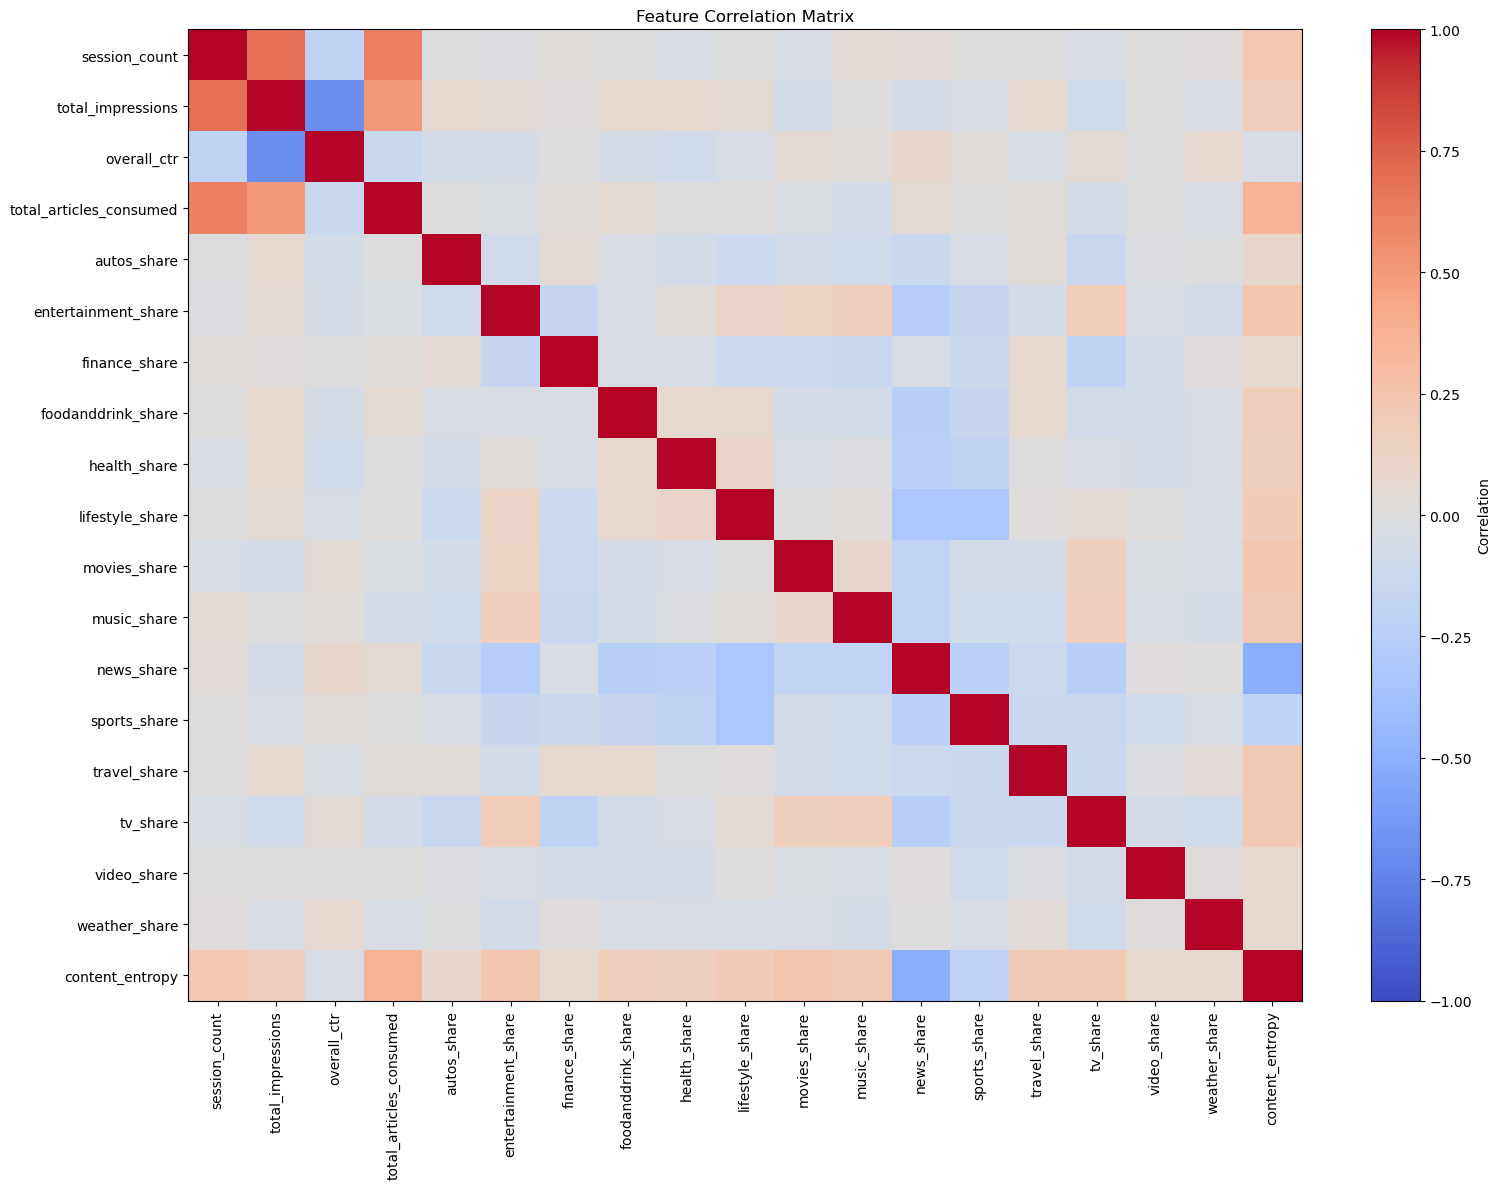

In [23]:
corr = X.corr()

plt.figure(figsize=(16, 12))

plt.imshow(
    corr,
    aspect="auto",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [24]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)

print(
    "Mean after scaling:",
    np.round(X_scaled.mean(axis=0).mean(), 4)
)

print(
    "Average standard deviation:",
    np.round(X_scaled.std(axis=0).mean(), 4)
)

Scaled shape: (32820, 19)
Mean after scaling: 0.0
Average standard deviation: 1.0


In [25]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

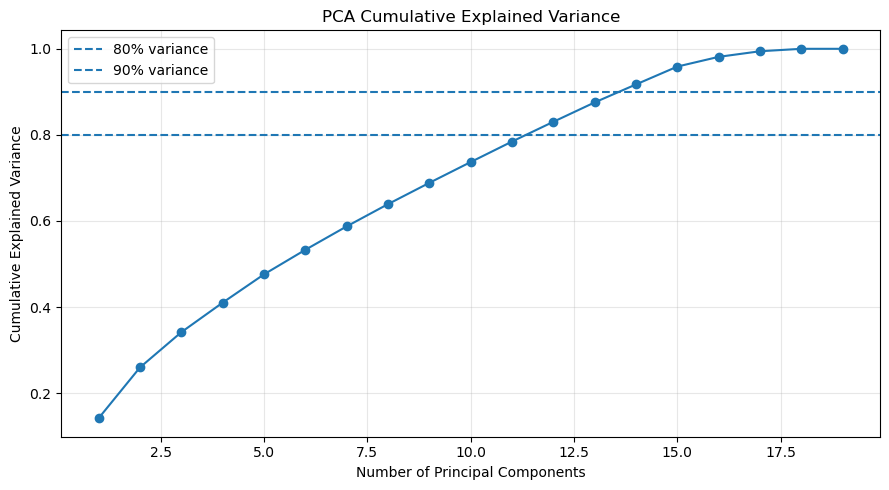

In [26]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.80,
    linestyle="--",
    label="80% variance"
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90% variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
n_components_80 = np.argmax(
    cumulative_variance >= 0.80
) + 1

n_components_90 = np.argmax(
    cumulative_variance >= 0.90
) + 1

print(
    "Components required for 80% variance:",
    n_components_80
)

print(
    "Components required for 90% variance:",
    n_components_90
)

Components required for 80% variance: 12
Components required for 90% variance: 14


In [28]:
pca = PCA(
    n_components=n_components_80
)

X_pca = pca.fit_transform(X_scaled)

print("Original dimensions:", X_scaled.shape[1])
print("PCA dimensions:", X_pca.shape[1])

print(
    "Variance retained:",
    round(
        pca.explained_variance_ratio_.sum() * 100,
        2
    ),
    "%"
)

Original dimensions: 19
PCA dimensions: 12
Variance retained: 83.04 %


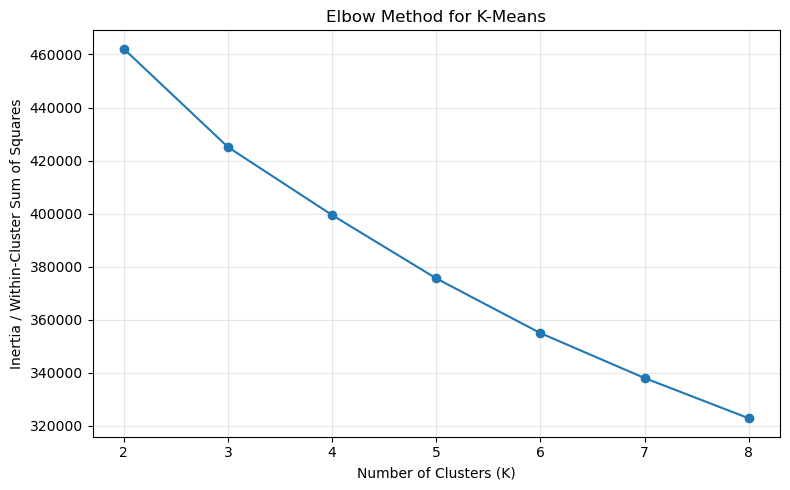

In [29]:
k_values = range(2, 9)

inertias = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_pca)

    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia / Within-Cluster Sum of Squares")
plt.title("Elbow Method for K-Means")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

K = 2: Silhouette Score = 0.1161
K = 3: Silhouette Score = 0.1035
K = 4: Silhouette Score = 0.1080
K = 5: Silhouette Score = 0.1102
K = 6: Silhouette Score = 0.1149
K = 7: Silhouette Score = 0.1216
K = 8: Silhouette Score = 0.1303


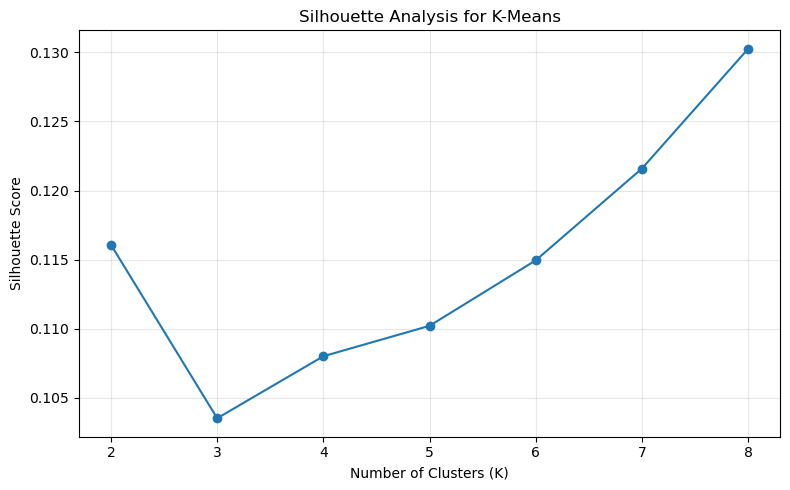

In [30]:
silhouette_scores = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels,
        sample_size=10000,
        random_state=42
    )

    silhouette_scores.append(score)

    print(
        f"K = {k}: "
        f"Silhouette Score = {score:.4f}"
    )
    
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for K-Means")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
candidate_ks = [4, 6, 7,8]

for k in candidate_ks:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_pca)

    counts = pd.Series(labels).value_counts().sort_index()
    percentages = counts / len(labels) * 100

    print(f"\nK = {k}")
    print("-" * 30)

    for cluster in counts.index:
        print(
            f"Cluster {cluster}: "
            f"{counts[cluster]:5d} users "
            f"({percentages[cluster]:.1f}%)"
        )


K = 4
------------------------------
Cluster 0:  8764 users (26.7%)
Cluster 1: 10426 users (31.8%)
Cluster 2: 10803 users (32.9%)
Cluster 3:  2827 users (8.6%)

K = 6
------------------------------
Cluster 0:  6890 users (21.0%)
Cluster 1:  4155 users (12.7%)
Cluster 2:  6672 users (20.3%)
Cluster 3:  7394 users (22.5%)
Cluster 4:  5305 users (16.2%)
Cluster 5:  2404 users (7.3%)

K = 7
------------------------------
Cluster 0:  2292 users (7.0%)
Cluster 1:  4382 users (13.4%)
Cluster 2:  4946 users (15.1%)
Cluster 3:  3946 users (12.0%)
Cluster 4:  4625 users (14.1%)
Cluster 5:  6243 users (19.0%)
Cluster 6:  6386 users (19.5%)

K = 8
------------------------------
Cluster 0:  1783 users (5.4%)
Cluster 1:  3953 users (12.0%)
Cluster 2:  6460 users (19.7%)
Cluster 3:  5357 users (16.3%)
Cluster 4:  2076 users (6.3%)
Cluster 5:  6045 users (18.4%)
Cluster 6:  4981 users (15.2%)
Cluster 7:  2165 users (6.6%)


In [32]:
k4_model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

k4_labels = k4_model.fit_predict(X_pca)

k4_users = ml_users.copy()
k4_users["cluster"] = k4_labels

k4_profile = (
    k4_users
    .groupby("cluster")[
        [
            "session_count",
            "total_impressions",
            "overall_ctr",
            "total_articles_consumed",
            "content_entropy"
        ]
    ]
    .mean()
    .round(3)
)

k4_profile

,session_count,total_impressions,overall_ctr,total_articles_consumed,content_entropy
cluster,,,,,
0,7.371,306.396,0.049,61.855,1.908
1,2.837,106.432,0.054,21.327,1.370
2,2.632,104.784,0.052,20.842,1.814
3,1.718,9.061,0.283,17.979,1.613


In [33]:
k4_category_profile = (
    k4_users
    .groupby("cluster")[category_features]
    .mean()
)

for cluster in range(4):

    print(f"\nCLUSTER {cluster}")
    print("-" * 30)

    top = (
        k4_category_profile
        .loc[cluster]
        .sort_values(ascending=False)
        .head(5)
    )

    for category, value in top.items():

        print(
            f"{category.replace('_share', ''):20s}"
            f"{value:.3f}"
        )


CLUSTER 0
------------------------------
news                0.280
sports              0.128
lifestyle           0.108
finance             0.090
tv                  0.065

CLUSTER 1
------------------------------
news                0.399
sports              0.207
finance             0.085
lifestyle           0.057
autos               0.046

CLUSTER 2
------------------------------
news                0.183
lifestyle           0.164
tv                  0.120
health              0.078
sports              0.076

CLUSTER 3
------------------------------
news                0.331
sports              0.149
tv                  0.094
lifestyle           0.084
finance             0.078


In [34]:
FINAL_K = 4

final_kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=10
)

ml_users["cluster"] = final_kmeans.fit_predict(X_pca)

In [35]:
persona_map = {
    0: "Power Explorer",
    1: "Focused News Loyalist",
    2: "Lifestyle Explorer",
    3: "Selective High-Intent Reader"
}

ml_users["persona"] = (
    ml_users["cluster"]
    .map(persona_map)
)

In [36]:
ml_users.to_csv(
    "C:\\Users\\admin\\ML_RESUME_PROJECT\\user_segments.csv",
    index=False
)

print(
    ml_users[
        ["user_id", "cluster", "persona"]
    ].head()
)

  user_id  cluster                persona
0    U100        2     Lifestyle Explorer
1  U10001        1  Focused News Loyalist
2  U10003        1  Focused News Loyalist
3  U10008        1  Focused News Loyalist
4  U10011        1  Focused News Loyalist


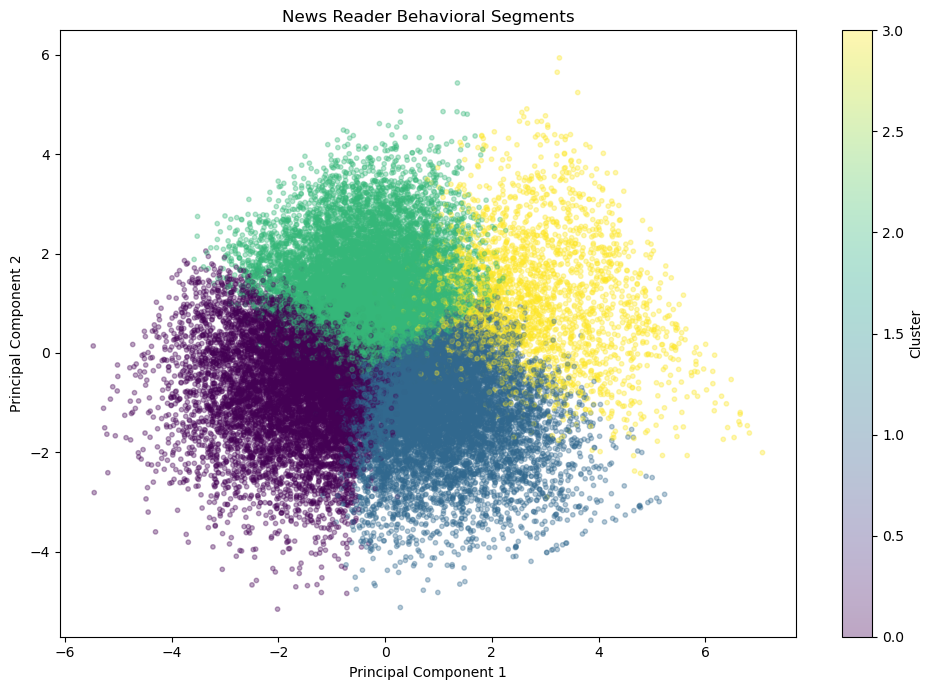

In [37]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=ml_users["cluster"],
    s=10,
    alpha=0.35,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("News Reader Behavioral Segments")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.tight_layout()
plt.show()

In [38]:
print(ml_users.shape)
print(X_pca.shape)

(32820, 30)
(32820, 12)


In [39]:
np.random.seed(42)

sample_size = 2000

sample_indices = np.random.choice(
    len(X_pca),
    size=sample_size,
    replace=False
)

X_sample = X_pca[sample_indices]

sample_users = ml_users.iloc[sample_indices].copy()

print("Sample shape:", X_sample.shape)

Sample shape: (2000, 12)


In [41]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

from scipy.cluster.hierarchy import linkage, dendrogram

In [42]:
linkage_matrix = linkage(
    X_sample,
    method="ward"
)

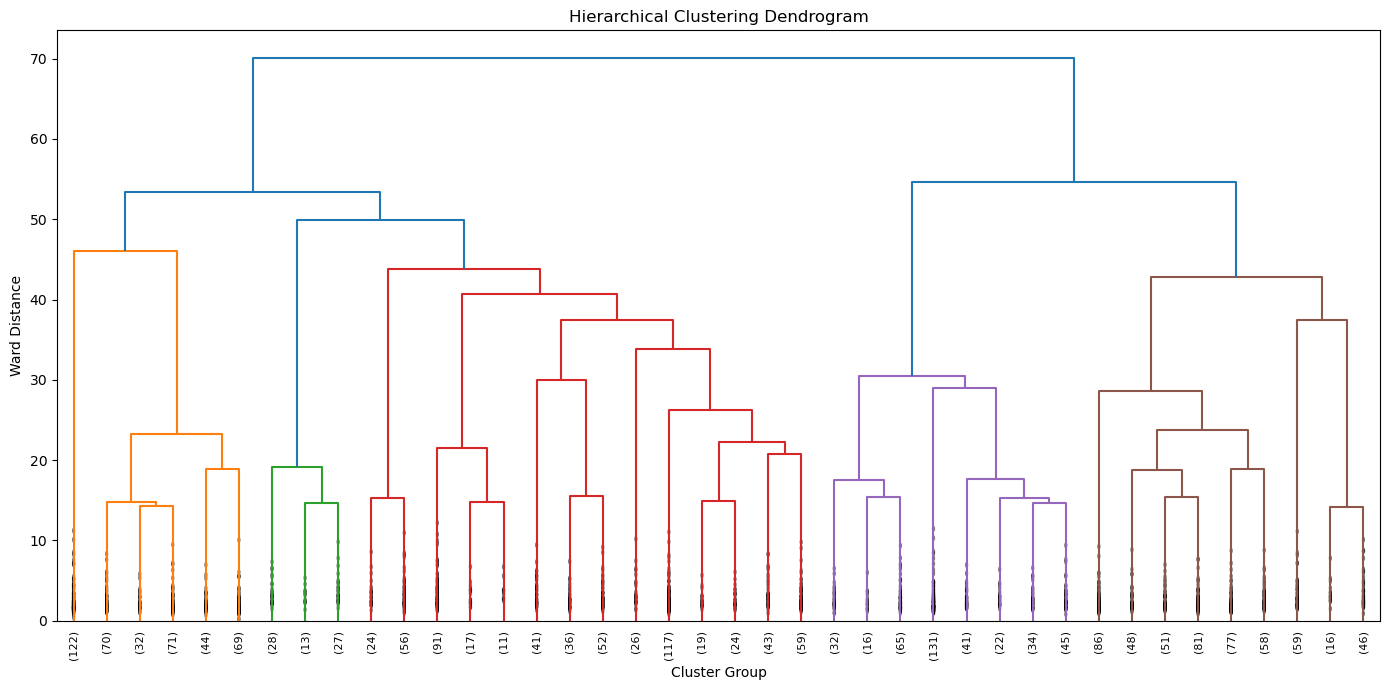

In [43]:
plt.figure(figsize=(14, 7))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=40,
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Group")
plt.ylabel("Ward Distance")

plt.tight_layout()
plt.show()

In [45]:
hierarchical_model = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(
    X_sample
)

sample_users["hierarchical_cluster"] = hierarchical_labels
sample_users["hierarchical_cluster"].value_counts().sort_index()

hierarchical_cluster
0    684
1    408
2    386
3    522
Name: count, dtype: int64

In [46]:
ari = adjusted_rand_score(
    sample_users["cluster"],
    sample_users["hierarchical_cluster"]
)

print(
    "Adjusted Rand Index:",
    round(ari, 4)
)

Adjusted Rand Index: 0.2333


In [47]:
baseline_model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

baseline_labels = baseline_model.fit_predict(
    X_pca
)

In [48]:
seeds = [0, 10, 20, 30, 42, 50, 100]

stability_results = []

for seed in seeds:

    model = KMeans(
        n_clusters=4,
        random_state=seed,
        n_init=10
    )

    labels = model.fit_predict(X_pca)

    ari = adjusted_rand_score(
        baseline_labels,
        labels
    )

    stability_results.append(
        [seed, ari]
    )

stability_df = pd.DataFrame(
    stability_results,
    columns=[
        "random_seed",
        "adjusted_rand_index"
    ]
)

stability_df

,random_seed,adjusted_rand_index
0,0,0.983200
1,10,0.985248
2,20,0.961056
3,30,0.987500
4,42,1.000000
5,50,0.983488
6,100,0.960114


In [49]:
print(
    "Mean ARI:",
    round(
        stability_df["adjusted_rand_index"].mean(),
        4
    )
)

print(
    "Minimum ARI:",
    round(
        stability_df["adjusted_rand_index"].min(),
        4
    )
)

Mean ARI: 0.9801
Minimum ARI: 0.9601


In [50]:
persona_summary = pd.DataFrame({
    "Cluster": [0, 1, 2, 3],
    "Persona": [
        "Power Explorer",
        "Focused News Loyalist",
        "Lifestyle Explorer",
        "Selective High-Intent Reader"
    ],
    "Size (%)": [
        26.7,
        31.8,
        32.9,
        8.6
    ],
    "Key Behavior": [
        "Highest consumption and broadest category exploration",
        "Concentrated around news and sports",
        "Broad lifestyle, TV and health interests",
        "Low exposure but very high click propensity"
    ],
    "Product Strategy": [
        "Cross-category discovery and deeper feed experiences",
        "Topic-first personalization and targeted notifications",
        "Discovery-oriented recommendations across lifestyle verticals",
        "Fewer, high-confidence recommendations"
    ]
})

persona_summary

,Cluster,Persona,Size (%),Key Behavior,Product Strategy
0,0,Power Explorer,26.7,Highest consumption and broadest category expl...,Cross-category discovery and deeper feed exper...
1,1,Focused News Loyalist,31.8,Concentrated around news and sports,Topic-first personalization and targeted notif...
2,2,Lifestyle Explorer,32.9,"Broad lifestyle, TV and health interests",Discovery-oriented recommendations across life...
3,3,Selective High-Intent Reader,8.6,Low exposure but very high click propensity,"Fewer, high-confidence recommendations"


In [51]:
hierarchical_ari = adjusted_rand_score(
    sample_users["cluster"],
    sample_users["hierarchical_cluster"]
)

print(
    "K-Means vs Hierarchical ARI:",
    round(hierarchical_ari, 4)
)

K-Means vs Hierarchical ARI: 0.2333
